In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
# from loglike_phasemax_noise import LogLike
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 3/12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
print(f'SNR (time-max): {data_snr:.4f}')

print("Setting up log_density and prior functions...")


def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i = params[i]
        try:
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            x_stat = gwf.Xstat_timemax(loglike_obj.signal, h_temp)
            out[i] = float(x_stat.get() if hasattr(x_stat, 'get') else x_stat)
        except Exception:
            pass
    return out


def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u


print('Done setting up log-likelihood and prior.')

Using dt=5s, T=0.25yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
SNR (time-max): 2175.8140
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [ ]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris2_noise/int_3mth'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [4]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [5]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.021095  ,  0.620815  ,  0.852575  ,  0.424375  ,  0.315185  ],
        [ 0.06478925,  1.07774218,  0.83351326,  0.71865607, -0.22361185],
        [ 0.09651061,  0.22051735,  0.58272807,  0.9878443 ,  0.35937903],
        ...,
        [ 0.0482928 ,  0.74553615,  0.78983529,  0.29709958,  0.15108455],
        [ 0.0482976 ,  0.7455335 ,  0.7898417 ,  0.29711656,  0.15108954],
        [ 0.0482965 ,  0.74554086,  0.78983121,  0.29708197,  0.15106601]])]

In [ ]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([681.79778353,         -inf, 500.65700916, ..., 561.66099997,
        523.14137215, 516.43654063])]

In [7]:
sampler.now_covariances

[array([[ 1.00018557e-10,  8.50715063e-14, -4.27828725e-14,
         -8.68121059e-14, -1.11928270e-13],
        [ 8.50715063e-14,  1.00390020e-10, -1.96142220e-13,
         -3.97999445e-13, -5.13144162e-13],
        [-4.27828725e-14, -1.96142220e-13,  1.00098641e-10,
          2.00155364e-13,  2.58062093e-13],
        [-8.68121059e-14, -3.97999445e-13,  2.00155364e-13,
          1.00406143e-10,  5.23643168e-13],
        [-1.11928270e-13, -5.13144162e-13,  2.58062093e-13,
          5.23643168e-13,  1.00675138e-10]])]

In [ ]:
np.argmax(logden_list)

82749

In [ ]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[5.63862259, 1.1727771 , 0.84499254, 8.8912361 , 0.24532288]])

In [10]:
log_density(maxld_pt1)

array([7.32538504])

In [11]:
log_density([param_true])

array([10.51843535])

In [ ]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 9, 0.4]

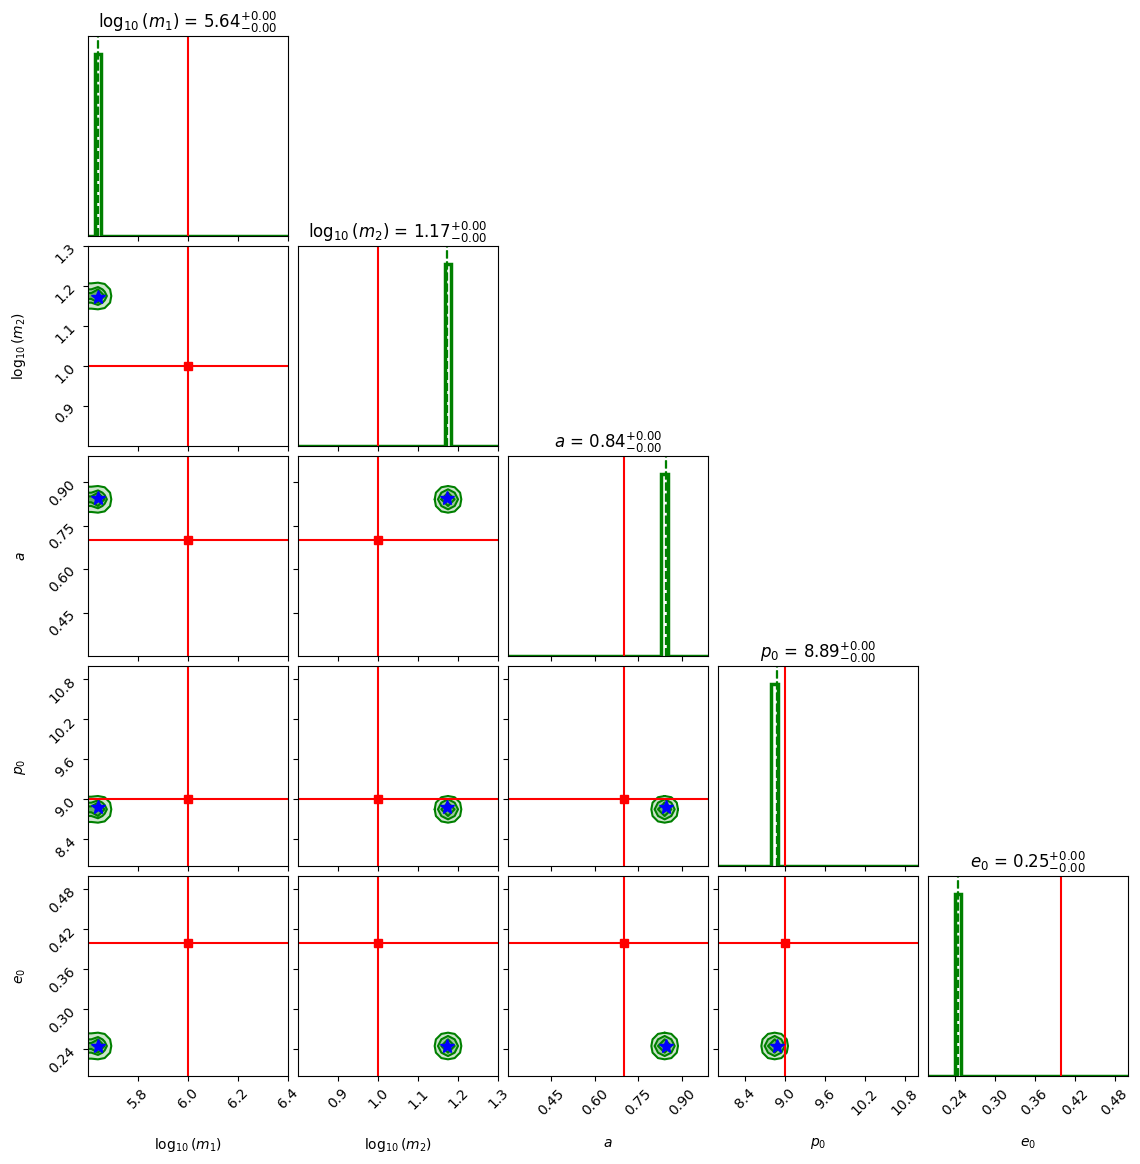

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [ ]:
w_norm = weights / weights.sum()
ess = 1.0 / np.sum(w_norm**2)
print(f"ESS: {ess:.1f}  ({100*ess/len(weights):.2f}% of N={len(weights)})")

ESS: 1.0  (0.00% of N=100000)


# connection plot

In [ ]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[5.63862259, 1.1727771 , 0.84499254, 8.8912361 , 0.24532288]])

In [ ]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [18]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [ ]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [20]:
logden_theory_proc1

array([ 7.32538504,  5.08776019,  5.0534856 ,  4.79985124,  4.85220664,
        5.18612955,  5.05524109,  4.96927034,  5.1643219 ,  4.81847665,
        5.13719786,  4.67790804,  4.78191513,  5.18735971,  4.97768771,
        5.02025711,  5.39869193,  5.08515344,  5.10680655,  5.41263027,
        5.20336869,  4.53520899,  4.81594984,  4.99709618,  5.1114267 ,
        5.45013978,  4.96759676,  5.01559711,  4.93024513,  5.04786022,
        4.83162793,  5.20387771,  4.95324662,  4.99263753,  4.77246517,
        5.13588762,  4.90700263,  4.97652804,  5.0163392 ,  5.08947613,
        4.69986955,  5.31838364,  4.84377189,  4.89099037,  4.7887803 ,
        4.70853793,  4.61502012,  4.63626455,  4.84105416, 10.51843535])

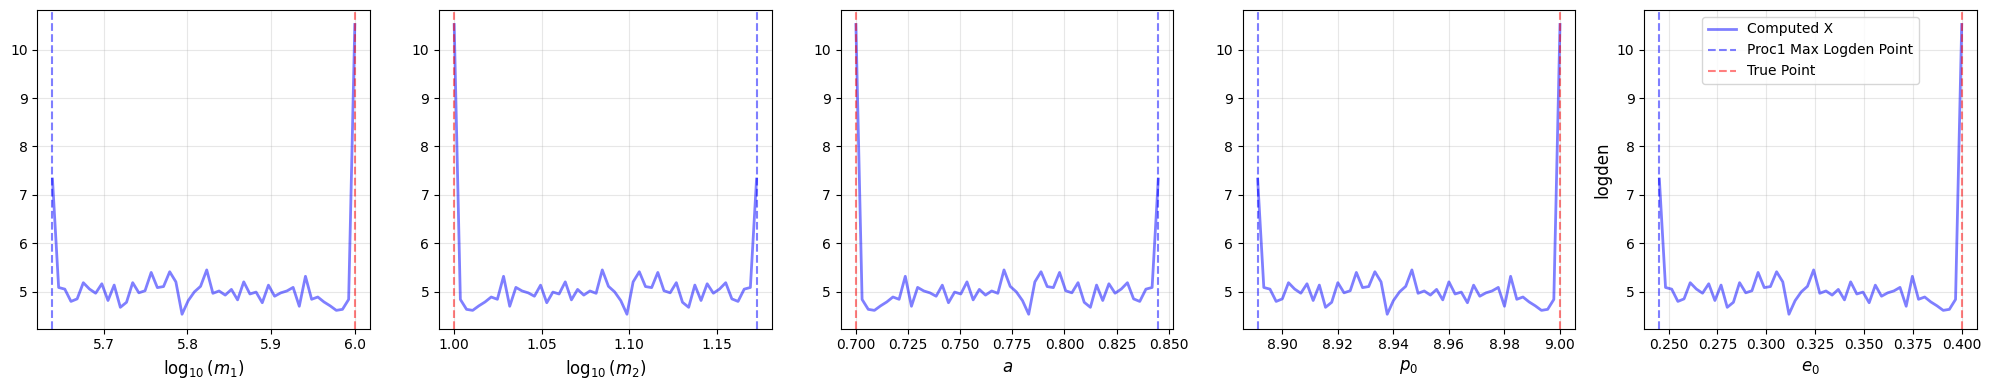

In [22]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed X')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
